<div style="text-align: center; margin-bottom: 40px; margin-top: 0;">
    <img src="./pics/sage-logo.jpg" alt="SAGE Logo" style="width: 200px; margin-top: 20px;">
    <img src="./pics/ndp-logo.png" alt="NDP Logo" style="width: 130px; height: 75px; margin-top: 20px; margin-left: 100px;">
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">Exploring a week of Sage Sensor Data</h1>


# Why Relative Humidity Falls When Temperature Rises
### Exploring a week of Sage sensor data (node W06C, BME680)

This notebook uses live measurements from the [Sage](https://sagecontinuum.org) sensor network to explore one of the most fundamental relationships in meteorology: **as air warms, its relative humidity falls — even when the actual amount of water vapor in the air barely changes.**

We'll pull one week of data from node **W06C**, whose **BME680** (a Bosch chip that measures temperature, humidity, pressure, and gas) reports both `env.temperature` and `env.relative_humidity`.

**What we'll do**

1. Query a week of data with `sage_data_client`
2. Reshape it, convert the temperatures to °F, and lightly clean it
3. Visualize how the two variables mirror each other over the daily cycle
4. Quantify the anti-correlation
5. Explain *why* with a little physics: saturation vapor pressure and dew point
6. Reframe it as vapor-pressure deficit, then bring in **NEON** flux data to see that atmospheric demand actually move water through an ecosystem

> **About Sage:** Sage is an NSF-funded network of AI-enabled edge sensor nodes deployed across the US. Every node streams its measurements to a public repository that anyone can query. You can browse node W06C on the [Sage portal](https://portal.sagecontinuum.org/node/W06C).

## 0. Setup

Before starting our analysis, we'll first import the necessary libraries. Prior to this step, make sure you've installed the dependencies listed in `requirements.txt` using the extension button.

In [1]:
import folium

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sage_data_client

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Locating the Node

The node we'll be working with is located near Jackson Lake, Wyoming. Let's do a quick mapping exercise to pinpoint its location.

In [2]:
lat, lon = 43.940154336, -110.644136675 # These coordinates can be seen in the sage portal

m = folium.Map(location=[lat, lon], zoom_start=12)
folium.Marker([lat, lon], popup="My Point").add_to(m)

m  # displaying the map

## 2. Query one week of data

`sage_data_client.query()` takes a time range plus a dictionary of filters and returns a tidy pandas DataFrame.

| filter | meaning |
|---|---|
| `vsn: "W06C"` | which node we want (its ID) |
| `name: "env.temperature\|env.relative_humidity"` | measurement names — the `\|` acts as an OR (it's a regex) |
| `sensor: "bme680"` | only readings from the BME680 chip |

`start="-7d"` means "from 7 days ago until now". All timestamps come back in **UTC**; we convert them to US Central in section 3.

In [3]:
df = sage_data_client.query(
    start="-7d",
    filter={
        "vsn": "W06C",
        "name": "env.temperature|env.relative_humidity",
        "sensor": "bme680",
    },
)

assert len(df) > 0, "No data returned — the node may have been offline. Try start='-30d' or another vsn."

print(f"Retrieved {len(df):,} records, "
      f"{df.timestamp.min():%Y-%m-%d %H:%M} to {df.timestamp.max():%Y-%m-%d %H:%M} UTC")
df.head()

Retrieved 40,290 records, 2026-07-09 20:52 to 2026-07-16 20:52 UTC


,timestamp,name,value,meta.host,meta.job,meta.node,meta.plugin,meta.sensor,meta.task,meta.vsn,meta.zone
0,2026-07-09 20:52:55.296630198+00:00,env.relative_humidity,22.080,0000dca632ed6eb6.ws-rpi,Pluginctl,000048b02d3ae335,waggle/plugin-iio:0.7.0,bme680,wes-iio-bme680,W06C,shield
1,2026-07-09 20:53:25.318496658+00:00,env.relative_humidity,22.434,0000dca632ed6eb6.ws-rpi,Pluginctl,000048b02d3ae335,waggle/plugin-iio:0.7.0,bme680,wes-iio-bme680,W06C,shield
2,2026-07-09 20:53:55.345162079+00:00,env.relative_humidity,21.956,0000dca632ed6eb6.ws-rpi,Pluginctl,000048b02d3ae335,waggle/plugin-iio:0.7.0,bme680,wes-iio-bme680,W06C,shield
3,2026-07-09 20:54:25.351109985+00:00,env.relative_humidity,21.069,0000dca632ed6eb6.ws-rpi,Pluginctl,000048b02d3ae335,waggle/plugin-iio:0.7.0,bme680,wes-iio-bme680,W06C,shield
4,2026-07-09 20:54:55.378633625+00:00,env.relative_humidity,21.671,0000dca632ed6eb6.ws-rpi,Pluginctl,000048b02d3ae335,waggle/plugin-iio:0.7.0,bme680,wes-iio-bme680,W06C,shield


Each row is a single measurement in *long* (tidy) format: a `timestamp`, the measurement `name`, its `value`, plus `meta.*` columns describing where it came from. Quick sanity check on the ranges — the sensor reports temperature in °C (we'll convert to °F in the next step) and humidity should sit within 0–100 %:

In [4]:
df.groupby("name")["value"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
name,,,,,,,,
env.relative_humidity,20145.0,54.05,22.48,12.64,34.10,55.35,71.76,96.09
env.temperature,20145.0,20.71,7.85,7.92,14.42,18.96,27.80,37.60


## 3. Reshape for analysis

To compare the two signals we pivot them into side-by-side columns, convert temperature to **Fahrenheit**, and average into common **10-minute bins**: the raw cadence is much faster than the weather changes, and the two signals' raw timestamps don't line up exactly.

In [5]:
wide = (
    df.pivot_table(index="timestamp", columns="name", values="value", aggfunc="mean")
      .rename(columns={
          "env.temperature": "temp_F",
          "env.relative_humidity": "rh_pct",
      })
)

# The BME680 reports temperature in °C — convert to Fahrenheit
wide["temp_F"] = wide["temp_F"] * 9 / 5 + 32

# Light quality filter: discard physically implausible readings
wide["temp_F"] = wide["temp_F"].where(wide["temp_F"].between(-40, 140))
wide["rh_pct"] = wide["rh_pct"].where(wide["rh_pct"].between(0, 100))

# Average into 10-minute bins so both signals share a common time axis
data = wide.resample("10min").mean().dropna()

# Sage timestamps arrive in UTC. Both this node and the Konza NEON site are in US
# Central, so we view everything in Central for an intuitive day/night picture.
# (If your node is actually in another zone, set its own IANA name here instead.)
LOCAL_TZ = "America/Denver"
if LOCAL_TZ:
    data = data.tz_convert(LOCAL_TZ)

print(f"{len(data):,} ten-minute samples")
data.head()

1,009 ten-minute samples


name,rh_pct,temp_F
timestamp,,
2026-07-09 14:50:00-06:00,21.838333,85.5476
2026-07-09 15:00:00-06:00,20.872950,86.4149
2026-07-09 15:10:00-06:00,20.702750,85.4555
2026-07-09 15:20:00-06:00,22.645850,85.7579
2026-07-09 15:30:00-06:00,24.783700,86.0738


## 4. A week in one picture

Plotting both series with twin y-axes makes the pattern jump out: every daytime **temperature crest** (red) lines up with a **humidity trough** (blue), and vice versa at night — two near-mirror-image curves.

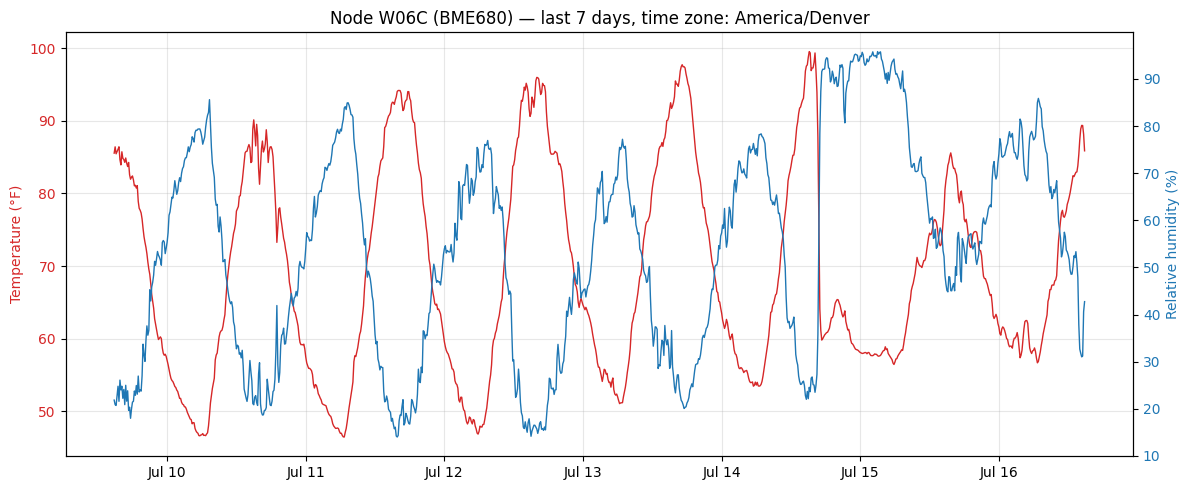

In [6]:
fig, ax_t = plt.subplots()

ax_t.plot(data.index, data["temp_F"], color="tab:red", lw=1)
ax_t.set_ylabel("Temperature (°F)", color="tab:red")
ax_t.tick_params(axis="y", labelcolor="tab:red")

ax_rh = ax_t.twinx()
ax_rh.plot(data.index, data["rh_pct"], color="tab:blue", lw=1)
ax_rh.set_ylabel("Relative humidity (%)", color="tab:blue")
ax_rh.tick_params(axis="y", labelcolor="tab:blue")
ax_rh.grid(False)

ax_t.set_title(f"Node W06C (BME680) — last 7 days, time zone: {data.index.tz}")
ax_t.xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz=data.index.tz))
plt.tight_layout()
plt.show()

The wiggles often match on shorter timescales too — a passing cloud or a cool gust shows up in both traces at once. Let's put a number on the relationship.

## 5. Quantifying the anti-correlation

Each dot below is one 10-minute average, colored by hour of day. The Pearson *r* measures how tightly the two variables are (inversely) linked, and the slope of the fit tells us how many percentage points of RH are lost per degree of warming *at this site, this week*.

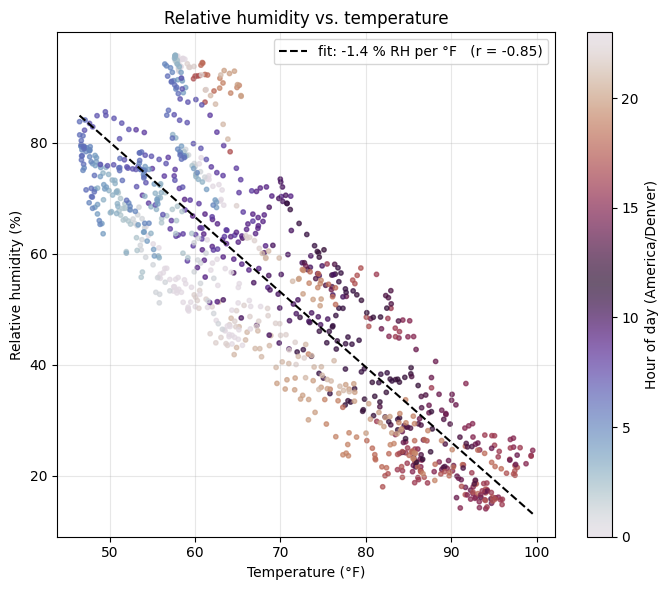

Pearson correlation: r = -0.853   (r² = 0.73)


In [7]:
r = data["temp_F"].corr(data["rh_pct"])

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    data["temp_F"], data["rh_pct"],
    c=data.index.hour, cmap="twilight", s=10, alpha=0.7,
)
fig.colorbar(sc, ax=ax, label=f"Hour of day ({data.index.tz})")

# Linear fit for reference
slope, intercept = np.polyfit(data["temp_F"], data["rh_pct"], 1)
xs = np.linspace(data["temp_F"].min(), data["temp_F"].max(), 100)
ax.plot(xs, slope * xs + intercept, "k--", lw=1.5,
        label=f"fit: {slope:.1f} % RH per °F   (r = {r:.2f})")

ax.set_xlabel("Temperature (°F)")
ax.set_ylabel("Relative humidity (%)")
ax.set_title("Relative humidity vs. temperature")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pearson correlation: r = {r:.3f}   (r² = {r**2:.2f})")

For a fair-weather week, *r* typically lands between about −0.7 and −0.95. Notice the **loops** in the scatter: mornings and evenings trace slightly different paths at the same temperature. That hysteresis is a hint that temperature isn't the *whole* story — the moisture content drifts a little over the week too. More on that in section 8.

## 6. The average day

Averaging by hour of day compresses the whole week into one "typical" diurnal cycle. The two curves are almost perfectly out of phase: humidity peaks around dawn (the coolest hour) and bottoms out in mid-afternoon (the warmest).

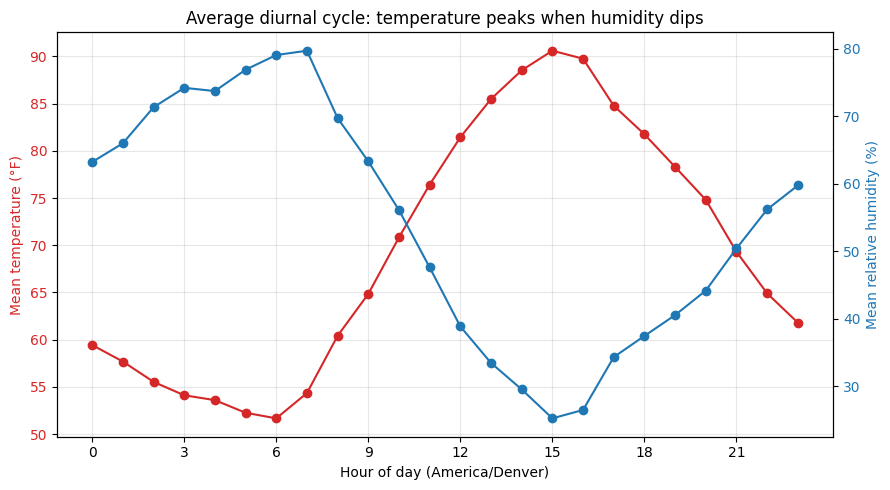

In [8]:
hourly = data.groupby(data.index.hour)[["temp_F", "rh_pct"]].mean()

fig, ax_t = plt.subplots(figsize=(9, 5))
ax_t.plot(hourly.index, hourly["temp_F"], "o-", color="tab:red")
ax_t.set_xlabel(f"Hour of day ({data.index.tz})")
ax_t.set_ylabel("Mean temperature (°F)", color="tab:red")
ax_t.tick_params(axis="y", labelcolor="tab:red")
ax_t.set_xticks(range(0, 24, 3))

ax_rh = ax_t.twinx()
ax_rh.plot(hourly.index, hourly["rh_pct"], "o-", color="tab:blue")
ax_rh.set_ylabel("Mean relative humidity (%)", color="tab:blue")
ax_rh.tick_params(axis="y", labelcolor="tab:blue")
ax_rh.grid(False)

ax_t.set_title("Average diurnal cycle: temperature peaks when humidity dips")
plt.tight_layout()
plt.show()

## 7. Why does warming *lower* relative humidity?

Relative humidity compares the water vapor that is **in** the air (vapor pressure $e$) with the most the air could hold at its current temperature — the *saturation vapor pressure* $e_s(T)$, given by the Magnus formula (which takes $T$ in **°C**; the code converts from °F automatically):

$$
\mathrm{RH} \;=\; 100 \times \frac{e}{e_s(T)},
\qquad
e_s(T) \;\approx\; 6.112\, \exp\!\left(\frac{17.62\,T}{243.12+T}\right)\ \text{hPa}
$$

The crucial fact — the Clausius–Clapeyron relation, approximated above by the Magnus formula — is that $e_s$ grows **nearly exponentially** with temperature — roughly **4 % per °F** (7 % per °C). The numerator $e$ is set by how much water vapor is actually present and usually changes slowly, but the denominator $e_s(T)$ swings with every warm afternoon. Warm the air and RH drops; cool it and RH climbs, potentially all the way to fog or dew.

The plot below makes it concrete: take air that is saturated (100 % RH) at 50 °F and warm it to 86 °F **without adding or removing any water** — its relative humidity collapses to about 29 %.

*("Hold" is a convenient shorthand — strictly, $e_s$ is the equilibrium vapor pressure over liquid water, a property of temperature alone.)*

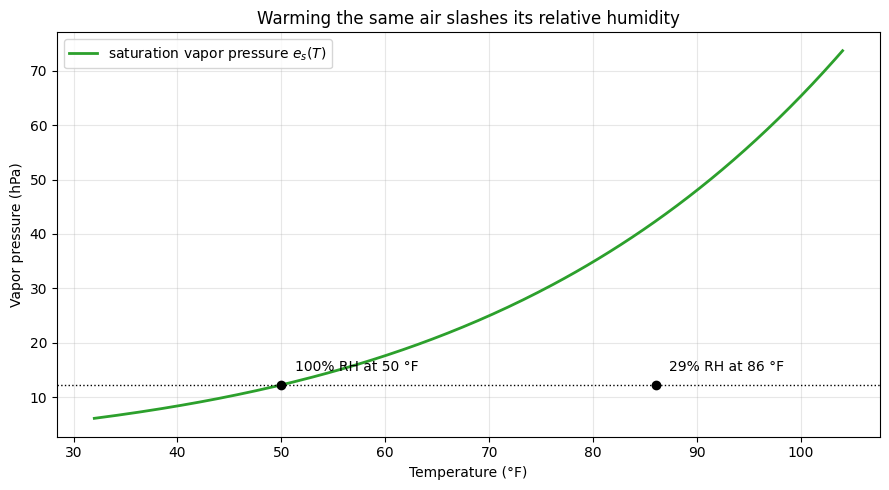

In [9]:
def f_to_c(T_f):
    """Convert °F to °C."""
    return (T_f - 32) * 5 / 9

def sat_vapor_pressure(T_f):
    """Saturation vapor pressure over water (hPa) from temperature in °F (Magnus)."""
    T_c = f_to_c(T_f)
    return 6.112 * np.exp(17.62 * T_c / (243.12 + T_c))

T = np.linspace(32, 104, 200)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(T, sat_vapor_pressure(T), color="tab:green", lw=2,
        label="saturation vapor pressure $e_s(T)$")

# The same air parcel (same actual vapor pressure) at two temperatures
e_actual = sat_vapor_pressure(50)  # air that is saturated at 50 °F
for T_pt in (50, 86):
    rh_pt = 100 * e_actual / sat_vapor_pressure(T_pt)
    ax.scatter([T_pt], [e_actual], zorder=5, color="k")
    ax.annotate(f"{rh_pt:.0f}% RH at {T_pt} °F",
                (T_pt, e_actual), textcoords="offset points", xytext=(10, 10))
ax.axhline(e_actual, color="k", ls=":", lw=1)

ax.set_xlabel("Temperature (°F)")
ax.set_ylabel("Vapor pressure (hPa)")
ax.set_title("Warming the same air slashes its relative humidity")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 8. Dew point — tracking the moisture itself

The **dew point** $T_d$ is the temperature the air would need to be cooled to in order to reach saturation. It depends only on the actual moisture content, which makes it the perfect control experiment:

- If the daily RH swings were caused by **moisture** coming and going, the dew point would swing just as hard.
- If they're caused by **temperature**, the dew point should stay comparatively flat while temperature (and with it RH) oscillates.

We can invert the Magnus formula to get $T_d$ from our measured $T$ and RH.

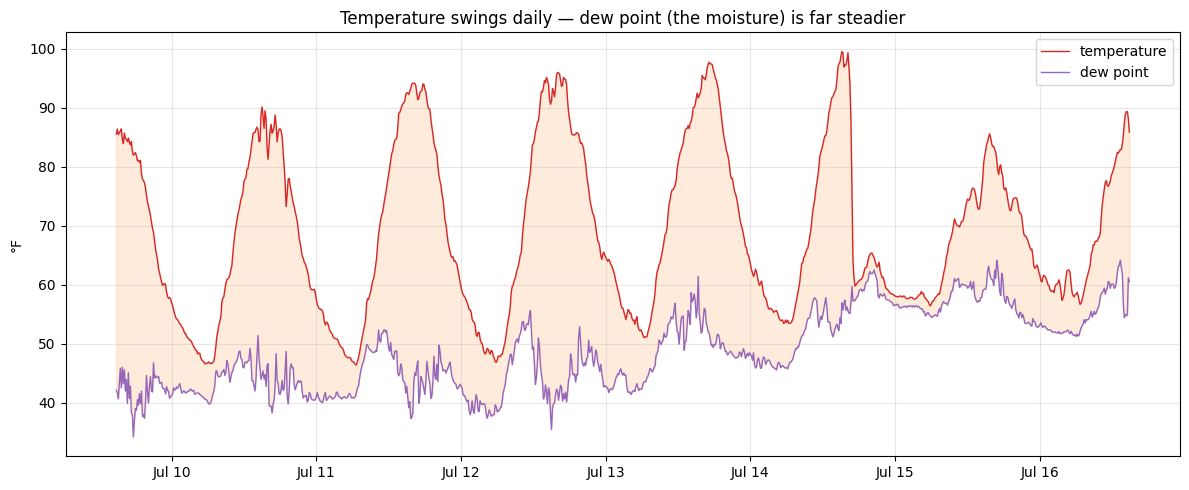

Correlation with temperature:
  relative humidity: r = -0.85
  dew point:         r = +0.20

Standard deviation over the week:
  temperature: 14.1 °F
  dew point:   6.7 °F


In [10]:
def dew_point(T_f, rh_pct):
    """Dew point (°F) from temperature (°F) and relative humidity (Magnus formula)."""
    a, b = 17.62, 243.12
    T_c = f_to_c(T_f)
    gamma = np.log(np.clip(rh_pct, 0.1, 100) / 100) + a * T_c / (b + T_c)
    return (b * gamma / (a - gamma)) * 9 / 5 + 32

data["dewpoint_F"] = dew_point(data["temp_F"], data["rh_pct"])

fig, ax = plt.subplots()
ax.plot(data.index, data["temp_F"], color="tab:red", lw=1, label="temperature")
ax.plot(data.index, data["dewpoint_F"], color="tab:purple", lw=1, label="dew point")
ax.fill_between(data.index, data["dewpoint_F"], data["temp_F"],
                color="tab:orange", alpha=0.15)
ax.set_ylabel("°F")
ax.set_title("Temperature swings daily — dew point (the moisture) is far steadier")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz=data.index.tz))
plt.tight_layout()
plt.show()

print("Correlation with temperature:")
print(f"  relative humidity: r = {data['temp_F'].corr(data['rh_pct']):+.2f}")
print(f"  dew point:         r = {data['temp_F'].corr(data['dewpoint_F']):+.2f}")
print("\nStandard deviation over the week:")
print(f"  temperature: {data['temp_F'].std():.1f} °F")
print(f"  dew point:   {data['dewpoint_F'].std():.1f} °F")

The gap between the two curves (the *dew point depression*) is itself a dryness gauge: wide in the warm afternoons, narrow at night. When the curves touch, RH is 100 % — fog or dew territory. And where the dew point *does* shift or step, that marks a genuine change in moisture (a new air mass, rain), which is exactly what produced the loops in the scatter plot of section 5.

## 9. Vapor-pressure deficit: the drying power of the air

The dew-point depression measured dryness in *degrees*. **Vapor-pressure deficit (VPD)** captures the same idea in units of *pressure* — and it's the number plant scientists and greenhouse growers actually reach for. It's the gap between what the air *could* hold and what it *is* holding:

$$
\mathrm{VPD} \;=\; e_s(T) - e \;=\; e_s(T)\,\Bigl(1 - \tfrac{\mathrm{RH}}{100}\Bigr)
$$

Because it folds temperature back in through $e_s(T)$, VPD is a better "thirst of the air" gauge than RH alone: 50 % RH on a hot afternoon pulls moisture from leaves and soil far harder than 50 % RH at dawn. We already have `sat_vapor_pressure()` from section 7, so VPD is essentially one line. (Divide by 10 for kPa, the usual agronomy unit.)

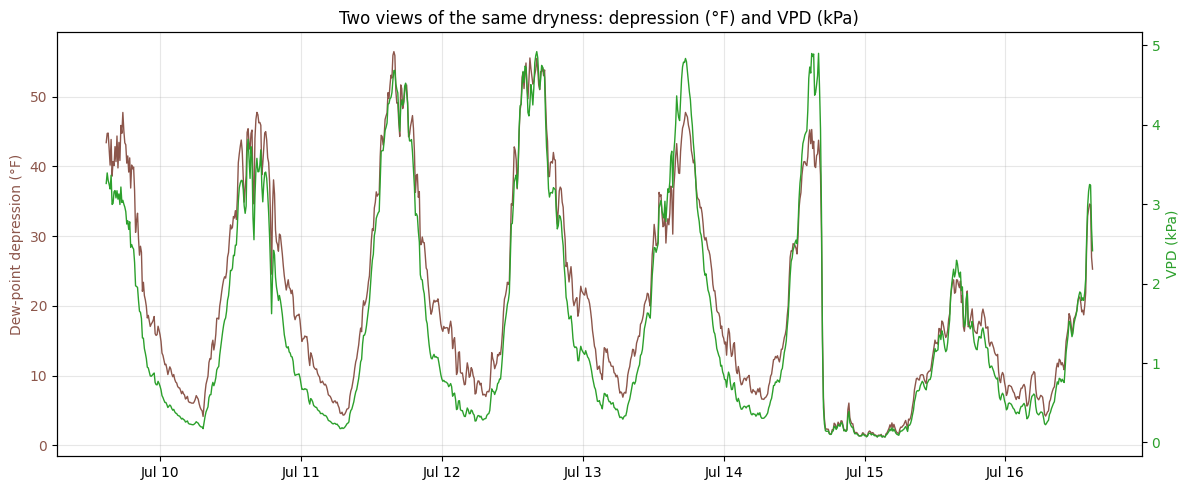

VPD ranges 0.07-4.92 kPa (mean 1.50).
Correlation with dew-point depression: r = 0.972


In [11]:
# es() returns hPa; VPD in kPa = es * (1 - RH/100) / 10
data["vpd_kpa"] = sat_vapor_pressure(data["temp_F"]) * (1 - data["rh_pct"] / 100) / 10

fig, ax_dep = plt.subplots()
dep = data["temp_F"] - data["dewpoint_F"]          # dew-point depression (°F)
ax_dep.plot(data.index, dep, color="tab:brown", lw=1)
ax_dep.set_ylabel("Dew-point depression (°F)", color="tab:brown")
ax_dep.tick_params(axis="y", labelcolor="tab:brown")

ax_vpd = ax_dep.twinx()
ax_vpd.plot(data.index, data["vpd_kpa"], color="tab:green", lw=1)
ax_vpd.set_ylabel("VPD (kPa)", color="tab:green")
ax_vpd.tick_params(axis="y", labelcolor="tab:green")
ax_vpd.grid(False)

ax_dep.set_title("Two views of the same dryness: depression (°F) and VPD (kPa)")
ax_dep.xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz=data.index.tz))
plt.tight_layout()
plt.show()

print(f"VPD ranges {data['vpd_kpa'].min():.2f}-{data['vpd_kpa'].max():.2f} kPa "
      f"(mean {data['vpd_kpa'].mean():.2f}).")
print(f"Correlation with dew-point depression: r = {data['vpd_kpa'].corr(dep):.3f}")

The two curves rise and fall together — the same physical story in different units — both cresting in the warm mid-afternoon when the air is thirstiest and collapsing toward zero overnight as the air nears saturation.

But VPD poses a question our node alone can't answer: *does that atmospheric thirst actually pull water out of an ecosystem, and by how much?* For that we need a sensor that measures water **leaving** the land — which brings in NEON.

## 10. Does that demand move water? Bringing in NEON flux data

Our BME680 measures the *demand* side (VPD). To see the *response* — how fast water actually leaves the land as plants transpire and soil evaporates — we turn to the [NSF NEON](https://www.neonscience.org) network. NEON's flux towers run **eddy-covariance** systems measuring ecosystem-scale exchanges of carbon, water, and energy. The water flux comes as **latent heat flux** (LE, in W m⁻²), which converts directly to **evapotranspiration** (ET, in mm).

**How the two datasets connect — read before running.** NEON towers sit at ecological field sites and NEON's flux data is quality-controlled with a lag of weeks to months — so it *won't* line up in time or space with your live 7-day Sage pull. We therefore treat this as a **mechanism study**, not a same-place/same-instant merge: pick one NEON flux site and a representative month, compute VPD from that site's own temperature and humidity (so demand and response are co-located at the tower), and watch how ET tracks VPD. The VPD from your Sage node is the same quantity — we compare magnitudes at the end.

**Access notes.** As of June 30 2026, NEON downloads require a free [account/API token](https://www.neonscience.org/about/user-accounts). This takes **two downloads**, because relative humidity isn't part of the flux bundle:

1. **Latent heat flux** from the eddy-covariance bundle `DP4.00200.001` (delivered as HDF5). `neonutilities` saves it as `.zip` archives under `filesToStack00200/`, so the cell unzips them, then reads the flux from the `fluxH2o` group.
2. **Co-located temperature and RH** from the Relative-humidity product `DP1.00098.001`, whose sensor reports both from the same instrument on the tower.

**Two spots may need tweaking on a different release**, and the cell prints what it found at each so you can check: the HDF5 flux path/field names, and the RH table/column names. If either search comes up empty, open the product's Quick Start Guide (or run `f.visit(print)` on the HDF5 file) and adjust the keys.

In [12]:
import glob, os, zipfile
import h5py
import neonutilities as nu
from matplotlib.collections import LineCollection
from dotenv import load_dotenv
load_dotenv()

# ---- choose a NEON flux site and month (independent of the Sage window) ----
NEON_SITE  = "KONZ"      # Konza Prairie, Kansas (tallgrass prairie, US Central); try "HARV" or "NIWO"
NEON_MONTH = "2024-07"   # a summer month shows the strongest VPD-ET dynamics
NEON_TOKEN = os.environ.get("NEON_TOKEN")

if not NEON_TOKEN:
    raise ValueError("NEON_TOKEN not found in environment — set it in a .env file or export it before running this notebook.")

LOCAL_TZ = "America/Chicago"

# ============ 1. Latent heat flux from the eddy-covariance bundle (HDF5) ============
save_dir = "neon/neon_ec"
nu.zips_by_product(dpid="DP4.00200.001", site=NEON_SITE,
                   startdate=NEON_MONTH, enddate=NEON_MONTH,
                   savepath=save_dir, package="basic",
                   check_size=False, token=NEON_TOKEN)

# neonutilities saves .zip archives under <save_dir>/filesToStack00200/ — unzip them first
zip_dir = os.path.join(save_dir, "filesToStack00200")
zips = (glob.glob(os.path.join(zip_dir, "**", "*.zip"), recursive=True)
        or glob.glob(os.path.join(save_dir, "**", "*.zip"), recursive=True))
assert zips, f"No NEON zip archives found under {save_dir} — check the token, site, and month."
for z in zips:
    with zipfile.ZipFile(z) as zf:
        zf.extractall(os.path.dirname(z))

h5_files = glob.glob(os.path.join(save_dir, "**", "*.h5"), recursive=True)
assert h5_files, f"Unzipped {len(zips)} archive(s) but found no .h5 file under {zip_dir}."

def _find_path(h5, *keys):
    """First HDF5 dataset path containing all keys (case-insensitive)."""
    found = []
    h5.visititems(lambda n, o: found.append(n)
                  if isinstance(o, h5py.Dataset) and all(k.lower() in n.lower() for k in keys) else None)
    return found[0] if found else None

with h5py.File(sorted(h5_files)[0], "r") as f:
    # Latent heat flux lives at dp04 -> fluxH2o -> nsae (net surface-atmosphere exchange)
    le_path = _find_path(f, "fluxH2o", "nsae") or _find_path(f, "fluxH2o", "flux")
    print("latent-heat-flux path:", le_path)
    assert le_path, "Could not locate the fluxH2o table; run f.visit(print) and adjust the search keys."
    rec  = f[le_path][:]
    tcol = 'timeBgn'
    vcol = 'flux'
    le_time = pd.to_datetime([t.decode() if isinstance(t, (bytes, bytearray)) else t
                              for t in rec[tcol]], utc=True, errors="coerce")
    flux = pd.Series(np.asarray(rec[vcol], float), index=le_time, name="LE_wm2")
    flux = flux[flux.index.notna()]
    flux.index = flux.index.floor("30min")
    flux = flux.groupby(level=0).mean()          # one value per 30-min

# ============ 2. Co-located temperature & RH from the Relative-humidity product ============
# RH is NOT in the EC bundle; DP1.00098 reports RH *and* air temperature from the same sensor.
rh_tables = nu.load_by_product(dpid="DP1.00098.001", site=NEON_SITE,
                               startdate=NEON_MONTH, enddate=NEON_MONTH,
                               package="basic", token=NEON_TOKEN)
rh_key = 'RH_30min'
rh = rh_tables[rh_key].copy()
rh_col = 'RHMean'
t_col  = 'tempRHMean'
print(f"RH table: {rh_key}  ->  using columns {rh_col!r} and {t_col!r}")
# NEON stacks every sensor position into one table, so each 30-min timestamp appears
# multiple times (one row per measurement height). Collapse to one row per timestamp
# by averaging across positions — otherwise the duplicate index breaks the merge.
rh.index = pd.to_datetime(rh["startDateTime"], utc=True, errors="coerce").dt.floor("30min")
rh = rh.loc[rh.index.notna(), [rh_col, t_col]].groupby(level=0).mean()

# ============ 3. Merge flux + met onto a common 30-min index ============
neon = pd.concat([flux,
                  rh[rh_col].rename("rh_pct_neon"),
                  rh[t_col].rename("temp_C_neon")], axis=1).sort_index()
neon = neon[np.isfinite(neon["LE_wm2"])]
if LOCAL_TZ:
    neon = neon.tz_convert(LOCAL_TZ)
print(f"\n{NEON_SITE} {NEON_MONTH}: {len(neon):,} half-hourly records after merge")
neon.head()

Finding available files
100%|██████████| 1/1 [00:05<00:00,  5.43s/it]


latent-heat-flux path: KONZ/dp04/data/fluxH2o/nsae


Finding available files
100%|██████████| 1/1 [00:02<00:00,  2.01s/it]
Stacking data files
100%|██████████| 3/3 [00:00<00:00,  7.80it/s]


RH table: RH_30min  ->  using columns 'RHMean' and 'tempRHMean'

KONZ 2024-07: 1,462 half-hourly records after merge


,LE_wm2,rh_pct_neon,temp_C_neon
2024-06-30 19:00:00-05:00,27.880218,68.575,23.1640
2024-06-30 19:30:00-05:00,14.135738,71.750,22.3300
2024-06-30 20:00:00-05:00,12.711532,71.530,22.0510
2024-06-30 20:30:00-05:00,14.181253,75.485,21.5850
2024-06-30 21:00:00-05:00,64.969130,82.355,20.4585


Now convert the water flux to evapotranspiration and derive VPD from the co-located tower temperature and humidity, so demand and response describe the same patch of land:

In [13]:
# Latent heat flux (W m^-2) -> evapotranspiration (mm hr^-1)
LAMBDA_V, RHO_W = 2.45e6, 1000.0        # J/kg (latent heat of vaporization), kg/m^3
neon["et_mm_hr"] = neon["LE_wm2"] / (LAMBDA_V * RHO_W) * 1000 * 3600
neon["et_mm_hr"] = neon["et_mm_hr"].clip(lower=0)   # ignore nighttime condensation (LE < 0)

# Co-located VPD from the NEON tower's own T and RH (reuse the section-7 Magnus helper)
if {"temp_C_neon", "rh_pct_neon"}.issubset(neon.columns):
    es_hpa = sat_vapor_pressure(neon["temp_C_neon"] * 9 / 5 + 32)   # °C -> °F -> es(hPa)
    neon["vpd_kpa_neon"] = (es_hpa * (1 - neon["rh_pct_neon"] / 100) / 10).clip(lower=0)

neon = neon.dropna(subset=["vpd_kpa_neon", "et_mm_hr"])
neon["hour"] = neon.index.hour
neon[["LE_wm2", "et_mm_hr", "vpd_kpa_neon"]].describe().round(2)

,LE_wm2,et_mm_hr,vpd_kpa_neon
count,1459.00,1459.00,1459.00
mean,98.15,0.15,1.01
std,129.14,0.18,0.71
min,-758.37,0.00,0.00
25%,6.60,0.01,0.44
50%,31.62,0.05,0.92
75%,176.10,0.26,1.50
max,516.50,0.76,3.50


Each dot below is one 30-minute flux interval, colored by hour of day. If VPD drove ET one-for-one we'd see a straight line; instead we see something more revealing.

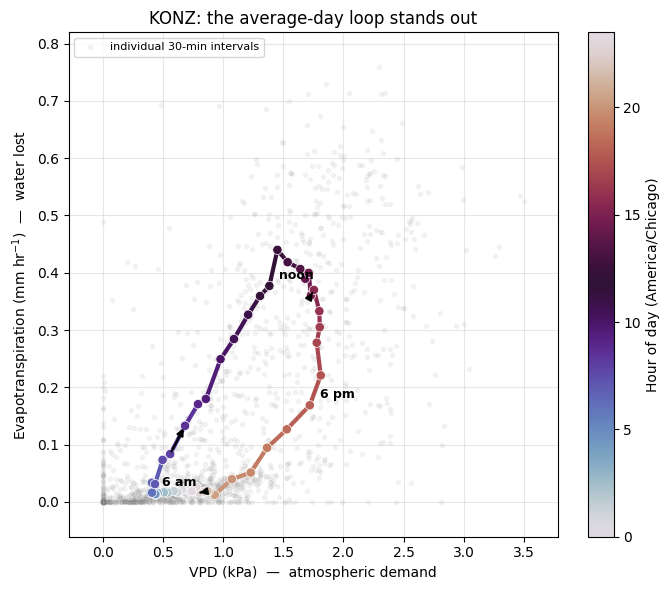

VPD-ET correlation:  all hours r = 0.67   daytime only r = 0.58


In [14]:
# Collapse the month to one point per half-hour of the day (the "average day")
tod  = neon.index.hour + neon.index.minute / 60
comp = neon.groupby(tod)[["vpd_kpa_neon", "et_mm_hr"]].mean()
pts  = comp[["vpd_kpa_neon", "et_mm_hr"]].to_numpy()
pts  = np.vstack([pts, pts[0]])                       # close the loop back to hour 0
hrs  = np.append(comp.index.to_numpy(), comp.index.to_numpy()[0])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(neon["vpd_kpa_neon"], neon["et_mm_hr"], s=8, alpha=0.08,
           color="0.5", label="individual 30-min intervals")

# average-day path, colored by time of day
segs = np.stack([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap="twilight", array=hrs[:-1], linewidths=3, zorder=2)
ax.add_collection(lc)
ax.scatter(comp["vpd_kpa_neon"], comp["et_mm_hr"], c=comp.index, cmap="twilight",
           s=45, zorder=3, edgecolors="white", linewidths=0.5)
fig.colorbar(lc, ax=ax, label=f"Hour of day ({neon.index.tz})")

_near = lambda h: int(np.argmin(np.abs(comp.index.to_numpy() - h)))   # nearest half-hour
for h in (8, 15, 22):                                 # direction arrows around the loop
    i = min(_near(h), len(comp) - 2)
    ax.annotate("", xy=pts[i + 1], xytext=pts[i],
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.6))
for h, txt in [(6, "6 am"), (12, "noon"), (18, "6 pm")]:   # label key hours
    row = comp.iloc[_near(h)]
    ax.annotate(txt, (row["vpd_kpa_neon"], row["et_mm_hr"]),
                textcoords="offset points", xytext=(7, 5), fontsize=9, fontweight="bold")

ax.set_xlabel("VPD (kPa)  —  atmospheric demand")
ax.set_ylabel("Evapotranspiration (mm hr$^{-1}$)  —  water lost")
ax.set_title(f"{NEON_SITE}: the average-day loop stands out")
ax.margins(0.08)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

r_all = neon["vpd_kpa_neon"].corr(neon["et_mm_hr"])
day = neon[neon["et_mm_hr"] > 0.02]
print(f"VPD-ET correlation:  all hours r = {r_all:.2f}   "
      f"daytime only r = {day['vpd_kpa_neon'].corr(day['et_mm_hr']):.2f}")

And the average day makes the timing explicit:

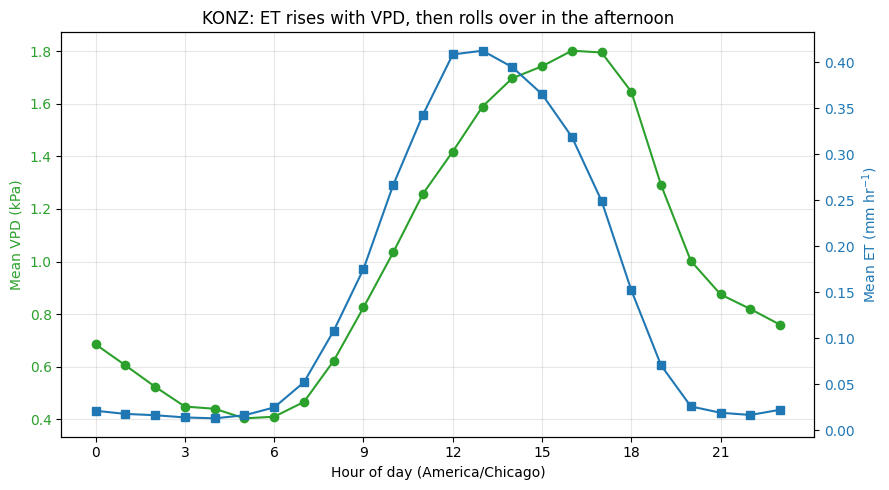

In [15]:
di = neon.groupby("hour")[["vpd_kpa_neon", "et_mm_hr"]].mean()

fig, ax_v = plt.subplots(figsize=(9, 5))
ax_v.plot(di.index, di["vpd_kpa_neon"], "o-", color="tab:green")
ax_v.set_xlabel(f"Hour of day ({neon.index.tz})")
ax_v.set_ylabel("Mean VPD (kPa)", color="tab:green")
ax_v.tick_params(axis="y", labelcolor="tab:green")
ax_v.set_xticks(range(0, 24, 3))

ax_e = ax_v.twinx()
ax_e.plot(di.index, di["et_mm_hr"], "s-", color="tab:blue")
ax_e.set_ylabel("Mean ET (mm hr$^{-1}$)", color="tab:blue")
ax_e.tick_params(axis="y", labelcolor="tab:blue")
ax_e.grid(False)

ax_v.set_title(f"{NEON_SITE}: ET rises with VPD, then rolls over in the afternoon")
plt.tight_layout()
plt.show()

Three things stand out, and together they tell the whole story:

- **ET rises and falls with VPD.** Both track the daily march of the sun, so across all hours they move together — thirstier air really does coincide with more water leaving the ecosystem.
- **Radiation gates it.** Transpiration needs sunlight, so ET drops to essentially zero overnight no matter what VPD is doing. Much of that tidy all-hours correlation is really the shared day/night rhythm; the air's demand only turns into water loss when the sun is up.
- **Within daylight the link loosens — the afternoon rollover.** ET tends to peak *earlier* than VPD and then ease off while VPD keeps climbing, so the daytime-only correlation is typically the weaker of the two numbers printed above. That lag traces a loop in the scatter and is the fingerprint of **stomatal regulation**: when the air gets too thirsty, plants partly close their stomata to avoid dehydrating, capping their water loss. It's the same behavior — atmospheric demand increasingly limiting ecosystem water and carbon exchange — documented across flux networks (Novick et al., 2016).

**Back to your Sage node.** The VPD you computed in section 9 is the identical quantity — the air's thirst — measured on an urban pole. Comparing the weekly means hints at the urban effect:

In [ ]:
print(f"Mean VPD, Sage node W06C : {data['vpd_kpa'].mean():.2f} kPa")
print(f"Mean VPD, NEON {NEON_SITE:<10}: {neon['vpd_kpa_neon'].mean():.2f} kPa")
print("\n(Different places and months, so read this as illustrative)")

Mean VPD, Sage node W06C : 1.50 kPa
Mean VPD, NEON KONZ      : 1.01 kPa

(Different places and months, so read this as illustrative: urban sites
 often run warmer and drier -> higher VPD -> greater atmospheric demand.)


## 11. What we learned

1. **Temperature and relative humidity are strongly anti-correlated** at node W06C, across the week and within the average day: RH peaks near dawn and bottoms out mid-afternoon.
2. **The driver is physics, not coincidence.** Saturation vapor pressure $e_s(T)$ grows about 4 % per °F, so with roughly constant moisture, daytime warming mechanically deflates RH.
3. **Dew point isolates the moisture.** It stays comparatively steady day-to-day, confirming the RH swings are temperature-driven; its slower drifts and steps mark real moisture changes (air masses, precipitation).
4. **VPD reframes the same signal as the air's drying power, and NEON flux data shows that demand really moves water** — ET rises with VPD, but only in daylight, and rolls over in the afternoon as plants close their stomata.

**Caveats worth remembering**

- The BME680 is mounted on the node itself, so absolute readings can carry enclosure and self-heating bias relative to a reference station. The *relationships* are robust; the absolute calibration may not be. (Pairing with a nearby NOAA ASOS station lets you correct it.)
- The Sage↔NEON comparison is a mechanism study, not a co-located merge: different places, different months, and NEON flux data lags by weeks to months.

**References**
- [Sage documentation](https://docs.sagecontinuum.org) 
- [sage-data-client](https://pypi.org/project/sage-data-client/)
- [NEON eddy-covariance bundle DP4.00200.001](https://data.neonscience.org/data-products/DP4.00200.001)
- [neonutilities](https://pypi.org/project/neonutilities/) 
- Alduchov & Eskridge (1996), *Improved Magnus form approximation of saturation vapor pressure*
- Novick et al. (2016), *The increasing importance of atmospheric demand for ecosystem water and carbon fluxes*, Nature Climate Change
- Bosch BME680 datasheet.